In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils.vis import plot_dist_matrix
from utils.misc import save_dict_as_json
from utils.data_transform import take_diff
from utils.clusterization import build_coint_mat, cluster_from_distance_matrix
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
df = pd.read_csv(
    "/home/danilach/mipt-stats/SberTs/Data/comb_df_v1.csv", index_col=0
)
df.index = pd.to_datetime(df.index)

In [12]:
df

,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,Сахар (средняя цена по России),...,Аммиак (FOB Черное море),Аммиачная селитра (FOB Черное море),Хлорид калия (CFR Ю-В Азия),Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия,Метанол,"Бензол, CFR Япония","Этилен, CFR Китай","Пшеница 12,5% FOB Ново, руб/т","Минтай б/г, Китай C&F руб/т","Рапсовое масло EU, руб/т"
2016-01-01,77.1504,7.78479,21.90863,68.46276,98.09368,23.065100,9.152530,9.823100,8.468390,37.847160,...,266.666667,199.375,278.750,1153.000000,185.40,556.000000,987.500000,13983.510000,88722.960,60010.149526
2016-02-01,77.2096,8.96166,21.93128,71.09693,95.96070,25.004510,10.344510,10.189000,9.031580,38.852860,...,260.500000,182.125,272.500,1163.000000,150.00,546.250000,927.500000,13878.425600,81070.080,60138.769333
2016-03-01,69.8752,8.62014,21.92008,72.08125,98.69213,24.905110,6.091980,10.360780,8.948070,38.674850,...,267.500000,180.300,267.500,1290.000000,164.75,625.000000,1173.750000,12525.129600,74067.712,53372.324136
2016-04-01,66.4805,8.72565,21.71031,67.15105,99.12532,23.893940,11.492900,10.144230,8.972940,37.198530,...,271.000000,172.000,267.500,1355.000000,179.90,642.000000,1192.500000,12365.373000,73128.550,53476.304786
2016-05-01,65.9479,8.86495,21.32462,69.34780,98.50837,22.985290,10.565500,9.918600,9.077650,37.418730,...,279.250000,154.750,251.875,1278.000000,201.25,631.250000,1160.000000,12423.265402,72542.690,53173.032926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,52.162194,...,513.817188,255.800,300.000,1440.000000,422.10,915.000000,873.333333,24208.800000,100870.000,94817.800000
2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,53.022727,...,489.909926,274.250,308.750,1460.000000,359.25,910.000000,893.333333,20629.245000,83538.000,86322.600000
2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,54.709091,...,455.534926,268.750,314.500,1593.335502,375.50,850.000000,856.250000,17558.280000,81766.500,85381.440000
2025-04-01,83.3000,10.65453,34.62168,114.79350,165.43448,27.125000,9.975682,12.296364,9.506818,54.772727,...,397.826593,256.250,334.000,1593.335502,322.25,768.750000,808.750000,17555.475000,87465.000,86111.375000


## Матрицы корреляции и коинтеграции

### Матрица корреляции

plot_dist_matrix(corr_mat) - строит график по переданной ей матрице


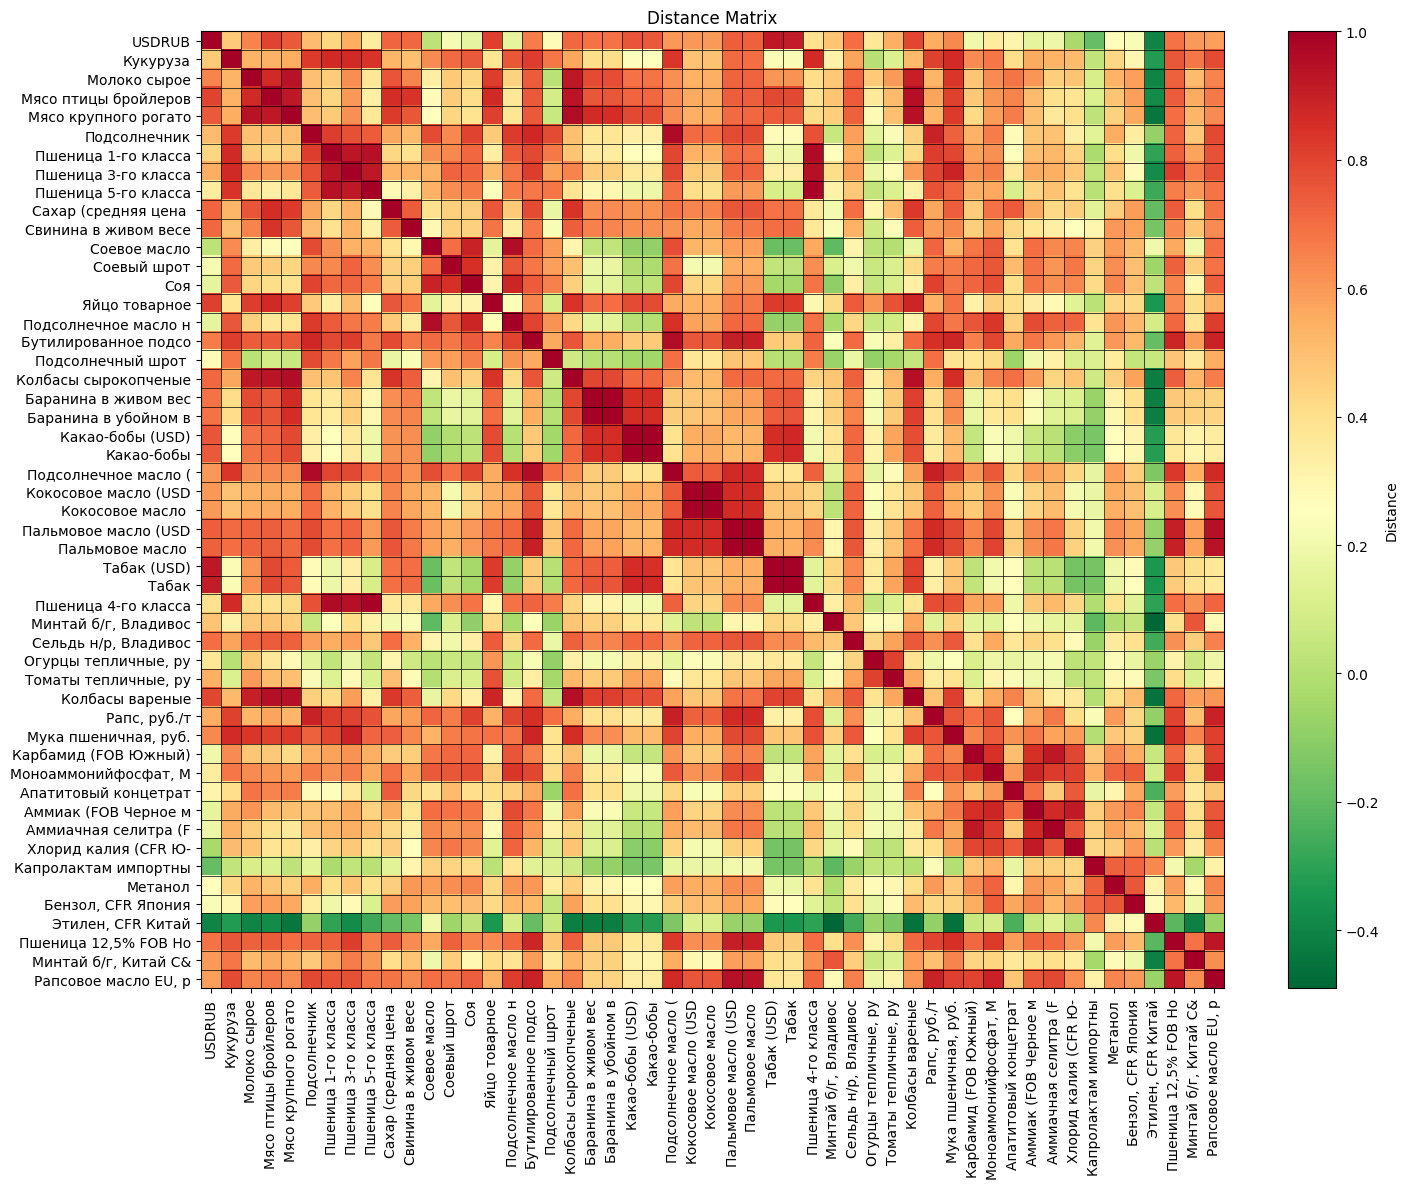

In [3]:
corr_mat = df.corr()
plot_dist_matrix(corr_mat)

### Матрица корреляции для k раз продиффиренцированного ряда

take_diff - дифференцирует ряды

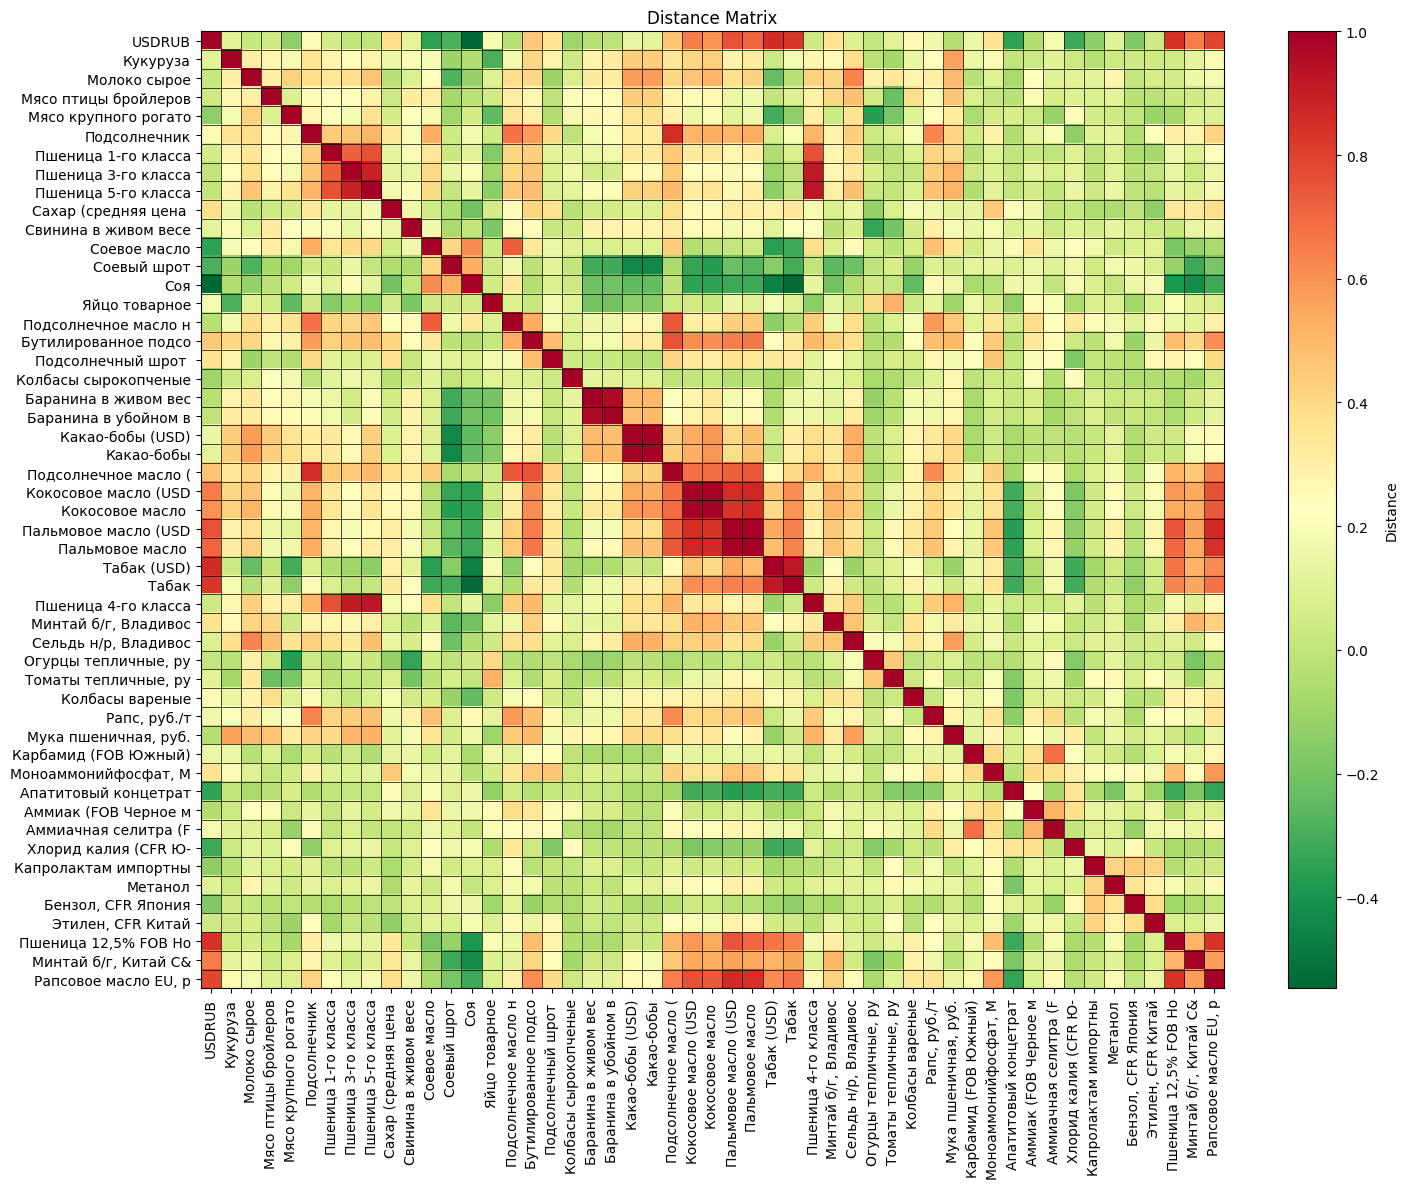

In [4]:
df_diffed = take_diff(df, 1)
corr_mat_diffed = df_diffed.corr()
plot_dist_matrix(corr_mat_diffed)

### Матрица коинтеграции

build_coint_mat - Применяет тест `Engle–Granger` ко всем парам рядов. (Т.е. фитит регрессию и применяет `ADF тест`). Из-за регрессии матрица несимметрична

Темы для рзамышления:

- Преобразование `pvalue` в расстояние

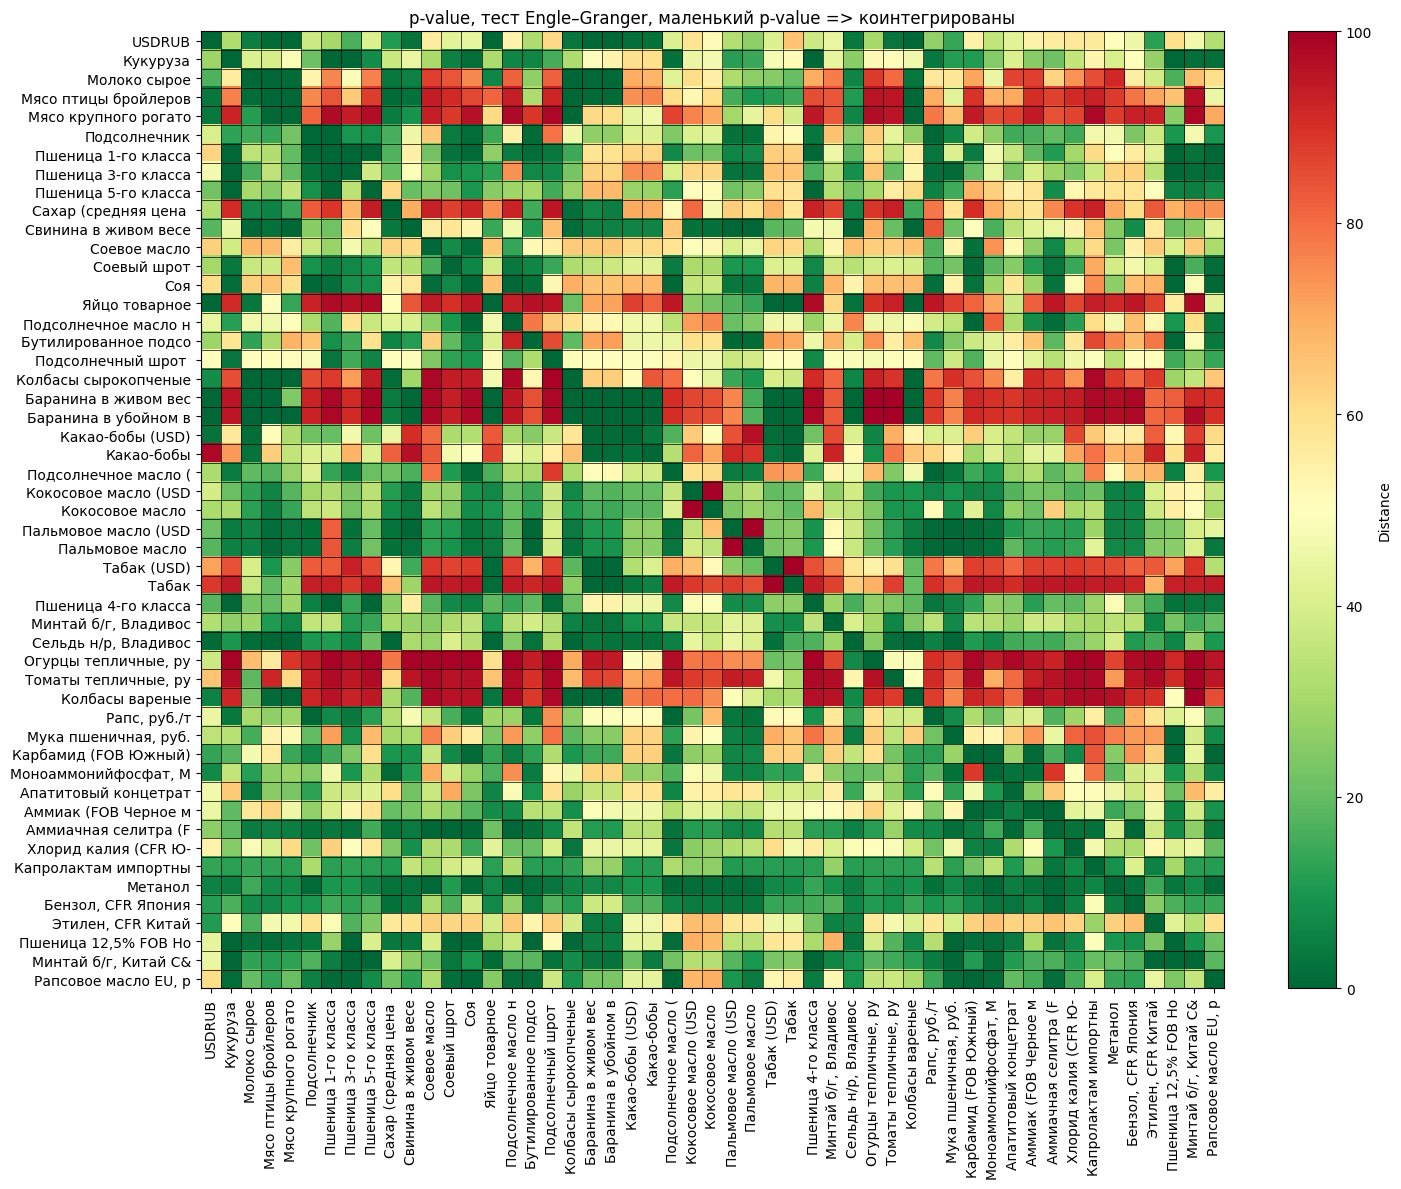

In [5]:
ff= build_coint_mat(df, test="Engle-Granger")
plot_dist_matrix(ff, title="p-value, тест Engle–Granger, маленький p-value => коинтегрированы")

TODO доделать тест `Johanson` 

## Clusterization

Строит иерархическую кластеризацию по матрице попарных расстояний. Иерархическая кластеризация отображается в виде дендрограммы

In [6]:
import seaborn as sns

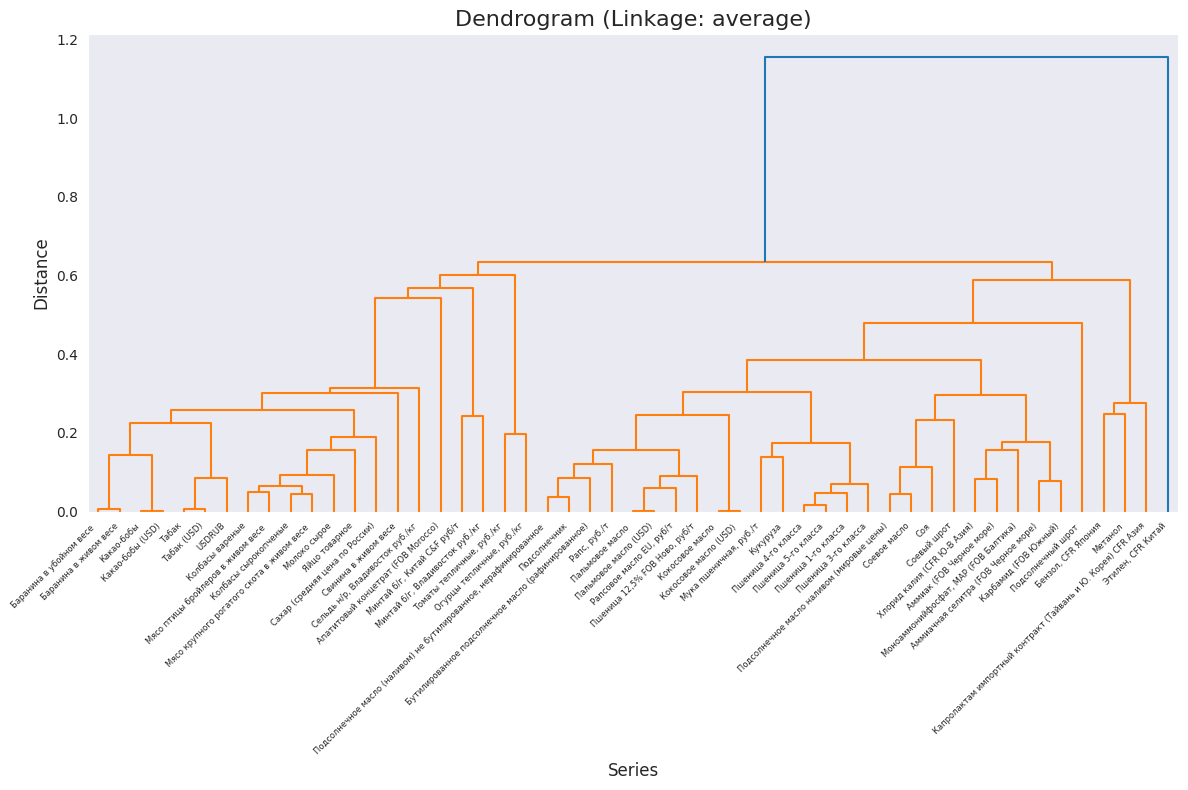

In [7]:
distance_matrix = 1 - corr_mat  # corr is not dist 
labels = df.columns

with sns.axes_style("dark"):
    cluster_from_distance_matrix(distance_matrix, labels, linkage_method="average")

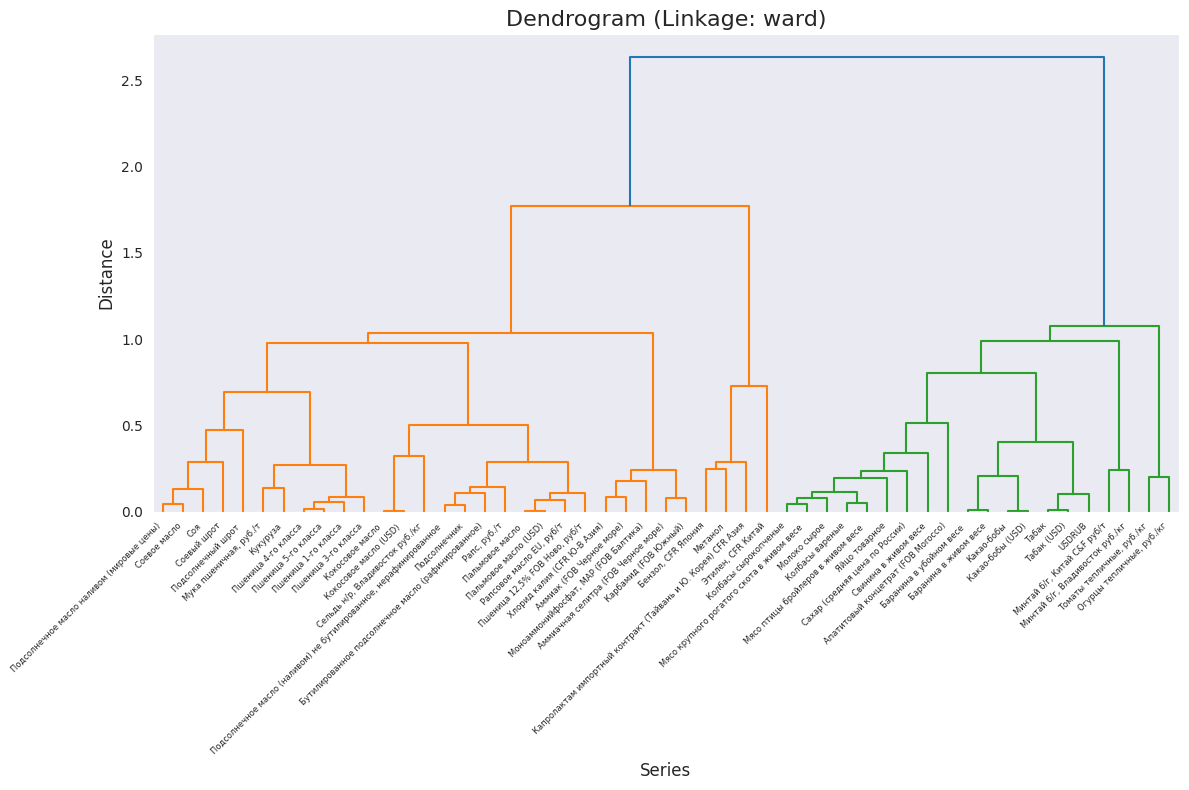

In [8]:
with sns.axes_style("dark"):
    cluster_from_distance_matrix(distance_matrix, labels, linkage_method="ward")

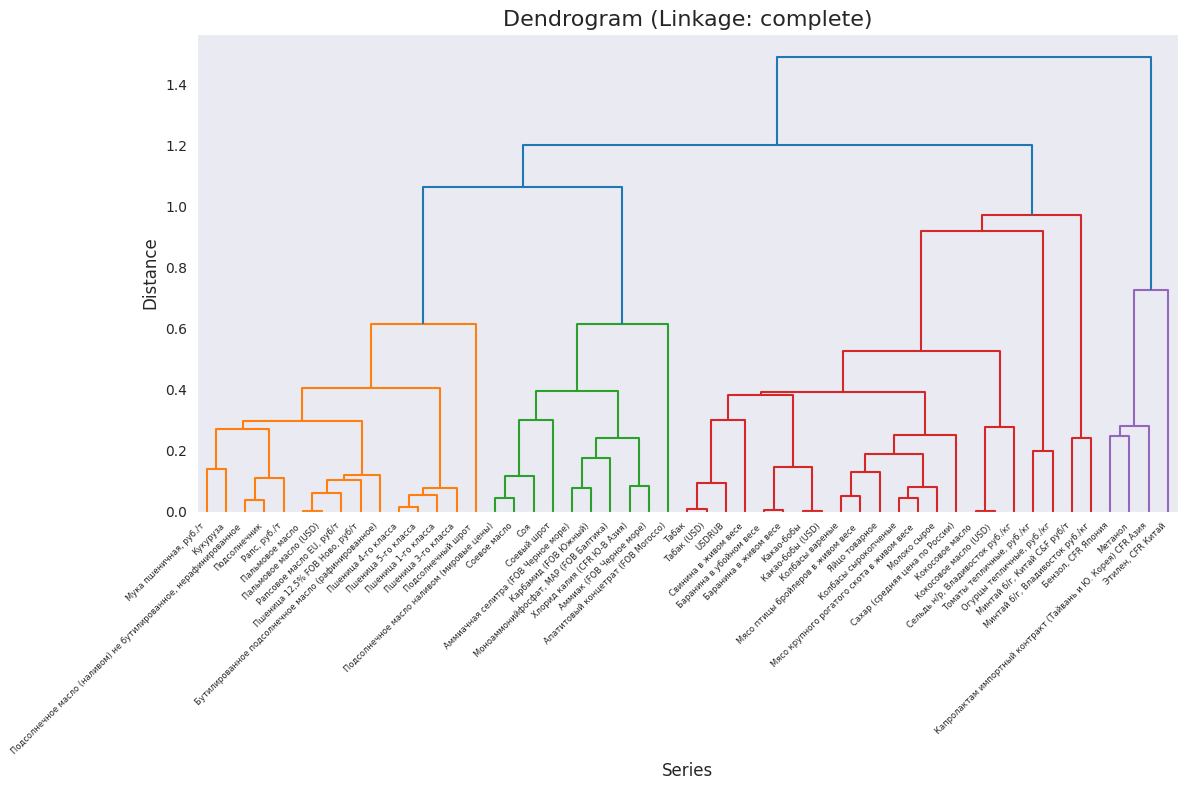

In [9]:
with sns.axes_style("dark"):
    cluster_from_distance_matrix(distance_matrix, labels, linkage_method="complete")

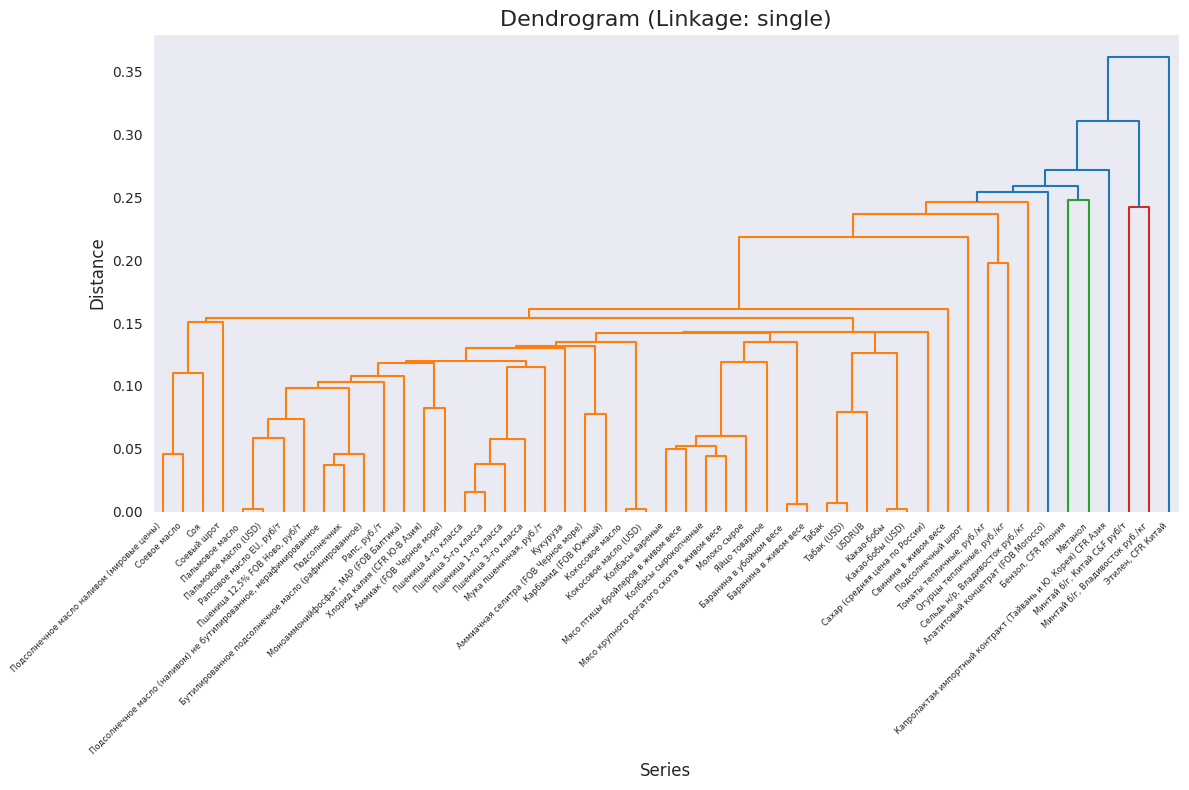

In [10]:
with sns.axes_style("dark"):
    cluster_from_distance_matrix(distance_matrix, labels, linkage_method="single")

## Прогнозирование кла

In [11]:
with sns.axes_style("dark"):
    cluster_from_distance_matrix(ff, labels, linkage_method="average")

ValueError: Distance matrix 'X' must be symmetric.